In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.animation as animation
from IPython.display import HTML
plt.rcParams["animation.html"] = "jshtml"

In [ ]:
#global variables
#bare MC movement
eps = 1e-3
L = 1.
k = (eps*L)**(2/3)
C0 = 2.1
tU = 4*k/(3*C0*eps)
sigma_u = np.sqrt(2*k/3)

#thermodynamics
pressure = 85000  #Pa
eps2=0.662 #from paper 

tau_turb = 1 #?
e0 = 611 #Pa at triple point
T00 = 273.16 #K at triple point
Lv0 = 2.5e6  #J/kg
Rv = 461.5
omega = 1/tau_turb



def partialPressure(p,q):
    return p/(1+eps2/q)
def equiPressure(T):
    return e0*np.exp( (Lv0 / Rv) *(1/T00 - 1/T))
def superSat(p, T, q):
    return partialPressure(p,q)/equiPressure(T)-1

#organize the concepts into objects
class Gas:
    def __init__(self, nParticles, box_size):
        self.nParticles = nParticles
        self.box_size = box_size
        self.initialize_particles() #pos and vel

    def initialize_particles(self):
        # Initialize particle positions randomly within the box
        positions = np.random.rand(self.nParticles, 2) * self.box_size
        
        # Initialize particle velocities based on the temperature
        velocities = np.random.normal(0, sigma_u, (self.nParticles, 2))
        
        self.positions, self.velocities = positions, velocities
    
    def update_positions(self, dt):
        #Update the position based on previous velocity
        self.positions += self.velocities * dt
        #Apply periodic boundary conditions
        self. positions = (self.positions + self.box_size) % self.box_size
        #Update the velocity based on the temperature difference
        self.velocities += -self.velocities/tU*dt + np.sqrt(2*sigma_u**2/tU)*np.random.normal(0, np.sqrt(dt), (self.nParticles, 2))

    def run_bare(self,nSteps, dt):
        self.initialize_particles()
        posHist = np.zeros((nSteps, self.nParticles, 2))
        for i in tqdm(range(nSteps)):
            posHist[i] = self.positions
            self.update_positions(dt)
        return posHist
    
    def animate(self, posHist, dt):
        fig, ax = plt.subplots()
        scat = ax.scatter(posHist[0,:,0], posHist[0,:,1], s=10)
        ax.set_xlim(0, self.box_size)
        ax.set_ylim(0, self.box_size)
        def update(frame):
            scat.set_offsets(posHist[frame])
            return scat,
        ani = animation.FuncAnimation(fig, update, frames=posHist.shape[0], interval=dt*1000, blit=True)
        plt.close(fig)
        return ani
    
    def initialize_thermo(self, Ct, Cq, Tin, Tout, QinCoeff = 1.1, QoutCoeff = 0.6):
        self.p = pressure
        self.Ct = Ct
        self.Cq = Cq
        self.Tin = Tin
        self.Tout = Tout
        self.Ts = np.zeros(self.nParticles) #temperature of each particle
        self.qs = np.zeros(self.nParticles) #humidity of each particle
        self.Ts = np.where((self.positions[:,0] > self.box_size/3) & (self.positions[:,0] < 2*self.box_size/3), Tin, Tout) #initial temperature based on position
        self.Qin=QinCoeff*eps2*(equiPressure(Tin)/(pressure-equiPressure(Tin))) 
        self.Qout=QoutCoeff*eps2*(equiPressure(Tout)/(pressure-equiPressure(Tout))) 
        self.qs = np.where((self.positions[:,0] > self.box_size/3) & (self.positions[:,0] < 2*self.box_size/3), self.Qin, self.Qout) #initial humidity based on position
        self.Tfixed = self.Ts.copy()#fixed temperature for relaxation
        self.qfixed = self.qs.copy() #fixed humidity for relaxation
        self.T_average = None #average temperature for average relaxation
        self.q_average = None #average humidity for average relaxation

        #Dynamic bin for average relaxation mode
        #nOfBins = max(10, self.nParticles // 100)
        nOfBins = 50
        self.T_average = np.zeros(nOfBins)
        self.q_average = np.zeros(nOfBins)

    def update_thermo(self, dt, relaxation_mode = "fixed"):
        #Update the temperature and humidity based on the current state
        #Initialize thermo check
        if not hasattr(self, 'Ct'):
            print("Thermodynamics not initialized. Call initialize_thermo(Ct, Cq, Tin, Tout)) first.")
            return
        #Calculate temperatures for every particle
        if relaxation_mode == "fixed":
            boolArr = (self.positions[:,0] > self.box_size/3) & (self.positions[:,0] < 2*self.box_size/3)
            self.Tfixed = np.where(boolArr, self.Tin, self.Tout)
            self.qfixed = np.where(boolArr, self.Qin, self.Qout)
            dTemp = -self.Ct*omega*(self.Ts - self.Tfixed)*dt
            self.Ts += dTemp
            self.qs += -self.Cq*omega*(self.qs - self.qfixed)*dt
        elif relaxation_mode == "average":
            for i in range(len(self.T_average)):
                bin_particles = (self.positions[:,0] > i*self.box_size/len(self.T_average)) & (self.positions[:,0] < (i+1)*self.box_size/len(self.T_average))
                if np.sum(bin_particles) > 0:
                    self.T_average[i] = np.mean(self.Ts[bin_particles])
                    self.q_average[i] = np.mean(self.qs[bin_particles])
                    #update the temperature and humidity of particles in the bin towards the average
                    self.Ts[bin_particles] += -self.Ct*omega*(self.Ts[bin_particles] - self.T_average[i])*dt
                    self.qs[bin_particles] += -self.Cq*omega*(self.qs[bin_particles] - self.q_average[i])*dt
        else:
            print("Invalid relaxation mode. Use 'fixed' or 'average'.")
        
        return self.Ts, self.qs
    
    def calculate_supersaturation(self):
        #Calculate the supersaturation for each particle
        return superSat(self.p, self.Ts, self.qs)

        
#test run bare and animate
gas = Gas(nParticles=100, box_size=1.0)
posHist = gas.run_bare(nSteps=100, dt=0.1)
ani = gas.animate(posHist, dt=0.1)
#HTML(ani.to_jshtml())
        


100%|██████████| 100/100 [00:00<00:00, 21079.02it/s]


In [3]:
#We need to wrote some tests for both thermodynamic modes
gas = Gas(nParticles=10000, box_size=1.0)

Tout = T00+20   
Tin = T00+1
dt = 0.001

gas.initialize_thermo(Ct=10, Cq=10, Tin=Tin, Tout=Tout, QinCoeff = 1.1, QoutCoeff = 0.6)
T_hist = np.zeros((100, 50))
q_hist = np.zeros((100, 50))
S_hist = np.zeros((100, 50))
for i in tqdm(range(1000)):
    Ts, qs = gas.update_thermo(dt=dt, relaxation_mode="average")
    S = superSat(gas.p, Ts, qs)
    ix = np.floor(gas.positions[:,0] * 50).astype(int)
    S_hist[i//10,:] = np.bincount(ix, weights=S, minlength=50)/(10000/50)
    gas.update_positions(dt=dt)



  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:11<00:00, 88.54it/s]


100%|██████████| 50000/50000 [01:02<00:00, 802.25it/s]


[-0.09846506 -0.10090232 -0.09700271 -0.09602781 -0.10187722 -0.09992742
 -0.10138977 -0.07750468 -0.09505291 -0.09992742 -0.09992742 -0.08627879
 -0.0911533  -0.0911533  -0.09943996 -0.08384154 -0.06282714  0.00985383
  0.00965577  0.00995287  0.01069562  0.0094577   0.010349    0.010349
  0.01089369  0.00921012  0.01000238  0.00901205  0.0088635   0.01054707
  0.0100519   0.01084417  0.01049755 -0.05834876 -0.09407801 -0.09359055
 -0.10236467 -0.0911533  -0.09554036 -0.09359055 -0.10821408 -0.10528937
 -0.09602781 -0.10431447 -0.10528937 -0.10577682 -0.10236467 -0.09554036
 -0.09651526 -0.09554036]


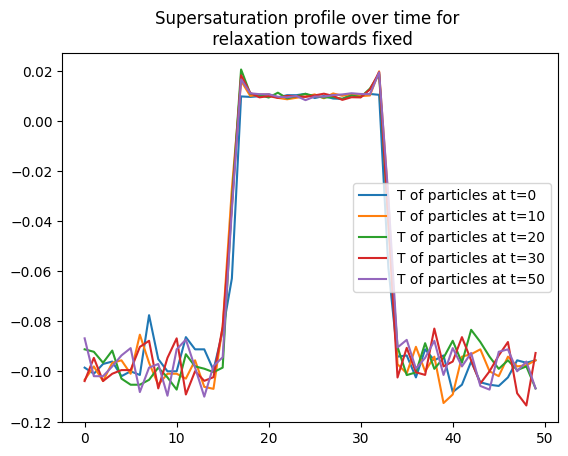

In [ ]:
def plot_history(history, mode):
    fig, ax = plt.subplots()
    ax.plot(history[0,:], label="T of particles at t=0")
    ax.plot(history[10,:], label="T of particles at t=10")
    ax.plot(history[20,:], label="T of particles at t=20")
    ax.plot(history[30,:], label="T of particles at t=30")
    ax.plot(history[50,:], label="T of particles at t=50")
    ax.set_title("Supersaturation profile over time for \n relaxation towards average" if mode == "average" else "Supersaturation profile over time for \n relaxation towards fixed")
    ax.legend()

def run_simulation(nOfParticles, nOfSteps, Cq, Ct, mode = "fixed"):
    Tout = T00+20 
    Tin = T00+4
    dt = 0.001
    gas = Gas(nParticles=nOfParticles, box_size=1.0)
    gas.initialize_thermo(Ct=Ct, Cq=Cq, Tin=Tin, Tout=Tout, QinCoeff = 1.01, QoutCoeff = 0.9)
    S_hist = np.zeros((100, 50))
    for i in tqdm(range(nOfSteps)):
        Ts, qs = gas.update_thermo(dt=dt, relaxation_mode=mode)
        S = superSat(gas.p, Ts, qs)
        ix = np.floor(gas.positions[:,0] * 50).astype(int)
        if i % (nOfSteps//100) == 0:
            S_hist[i//(nOfSteps//100),:] = np.bincount(ix, weights=S, minlength=50)/(nOfParticles/50)
        gas.update_positions(dt=dt)
    
    print(S_hist[0,:])
    plot_history(S_hist, mode = mode)

#run_simulation(nOfParticles=10000, nOfSteps=10000, Cq=10, Ct=10)
run_simulation(nOfParticles=10000, nOfSteps=50000, Cq=15, Ct=15)

100%|██████████| 10000/10000 [01:40<00:00, 99.50it/s]


[-0.09846506 -0.08384154 -0.10187722 -0.10090232 -0.09554036 -0.09554036
 -0.09749016 -0.09651526 -0.09407801 -0.10138977 -0.09992742 -0.10187722
 -0.09749016 -0.09456546 -0.10480192 -0.11503839 -0.06754957  0.01010142
  0.00881398  0.00980432  0.01020045  0.00935867  0.0088635   0.01015093
  0.00911108  0.010349    0.0088635   0.01079465  0.00817026  0.01024997
  0.01089369  0.00861591  0.01000238 -0.06301831 -0.10285212 -0.08774115
 -0.10138977 -0.0892035  -0.09602781 -0.09651526 -0.09602781 -0.09943996
 -0.10626428 -0.11357604 -0.10333957 -0.10772663 -0.0911533  -0.09066585
 -0.09505291 -0.10285212]


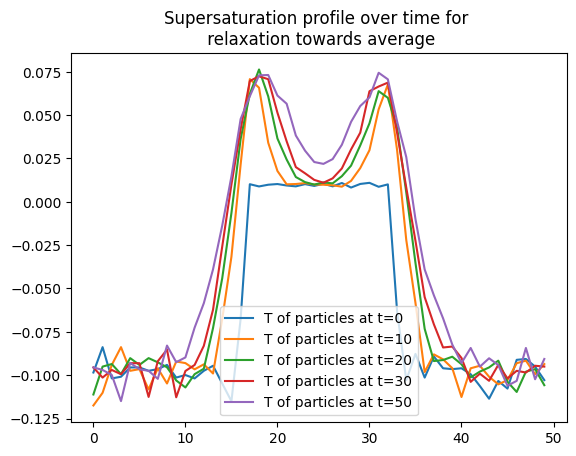

In [7]:
run_simulation(nOfParticles=10000, nOfSteps=10000, Cq=15, Ct=15,mode = "average")

100%|██████████| 100000/100000 [16:42<00:00, 99.79it/s]


[-0.09846506 -0.09602781 -0.09895251 -0.10090232 -0.09261565 -0.09992742
 -0.10382702 -0.08676624 -0.09797761 -0.09700271 -0.09505291 -0.09846506
 -0.09700271 -0.08871605 -0.09505291 -0.09797761 -0.06761424  0.01084417
  0.0100519   0.00950722  0.00970528  0.00970528  0.01000238  0.00940818
  0.00995287  0.01000238  0.01054707  0.00970528  0.00950722  0.0091606
  0.01010142  0.00891302  0.0097548  -0.05663483 -0.09700271 -0.11211369
 -0.09554036 -0.0901784  -0.10431447 -0.10333957 -0.10187722 -0.07945448
 -0.09407801 -0.10236467 -0.09164075 -0.09407801 -0.10577682 -0.09749016
 -0.09749016 -0.10577682]


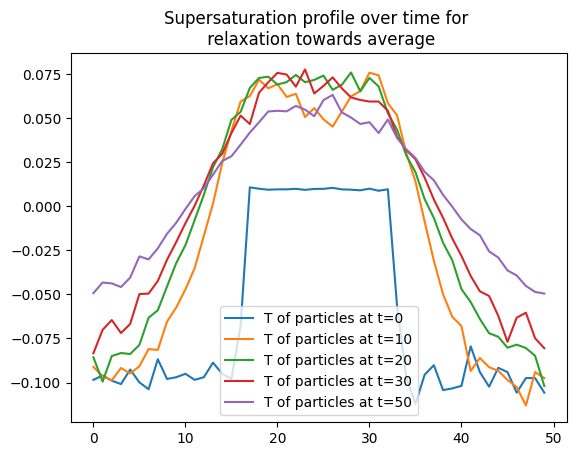

In [8]:
run_simulation(nOfParticles=10000, nOfSteps=100000, Cq=15, Ct=15,mode = "average")

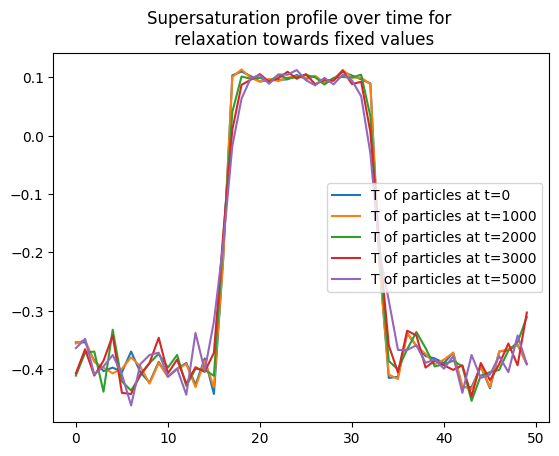

In [67]:
plt.plot(S_hist[0,:], label="T of particles at t=0")
plt.plot(S_hist[1,:], label="T of particles at t=1000")
plt.plot(S_hist[20,:], label="T of particles at t=2000")
plt.plot(S_hist[30,:], label="T of particles at t=3000")
plt.plot(S_hist[50,:], label="T of particles at t=5000")
plt.title("Supersaturation profile over time for \n relaxation towards fixed values")
plt.legend()

  0%|          | 0/60000 [00:00<?, ?it/s]

100%|██████████| 60000/60000 [1:03:51<00:00, 15.66it/s]


[-0.09617404 -0.101536   -0.09505291 -0.09685648 -0.09719769 -0.09846506
 -0.09685648 -0.09978118 -0.09905    -0.09875753 -0.09578408 -0.09914749
 -0.09675899 -0.0941755  -0.09675899 -0.09802636 -0.0554677   0.0096385
  0.00985169  0.00972774  0.00991615  0.00964841  0.01020372  0.00960875
  0.01042683  0.00975749  0.00984178  0.01000539  0.00993598  0.00970791
  0.01012439  0.00987153  0.00992607 -0.05868751 -0.09831883 -0.09817259
 -0.09422424 -0.09661275 -0.09802636 -0.10036612 -0.09680773 -0.09851381
 -0.10065859 -0.09846506 -0.09856255 -0.0955891  -0.09948871 -0.09812385
 -0.09490667 -0.09856255]


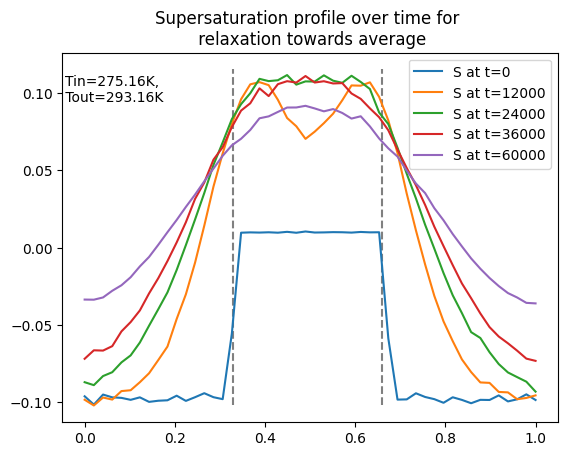

In [4]:
def plot_history(history, mode, nOfSteps,Tin,Tout):
    fig, ax = plt.subplots()
    ax.vlines(0.33, np.min(history), np.max(history), colors='gray', linestyles='dashed')
    ax.vlines(0.66, np.min(history), np.max(history), colors='gray', linestyles='dashed')
    ax.plot(np.linspace(0, 1, 50), history[0,:],  label=f"S at t={nOfSteps//50*0}")
    ax.plot(np.linspace(0, 1, 50), history[10,:], label=f"S at t={nOfSteps//50*10}")
    ax.plot(np.linspace(0, 1, 50), history[20,:], label=f"S at t={nOfSteps//50*20}")
    ax.plot(np.linspace(0, 1, 50), history[30,:], label=f"S at t={nOfSteps//50*30}")
    ax.plot(np.linspace(0, 1, 50), history[50,:], label=f"S at t={nOfSteps//50*50}")
    ax.text(0.1, 0.9, f"Tin={Tin}K,\n Tout={Tout}K", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    ax.set_title("Supersaturation profile over time for \n relaxation towards average" if mode == "average" else "Supersaturation profile over time for \n relaxation towards fixed")
    ax.legend()
    #save the plot
    plt.savefig(f"profiles/supersaturation_profile_{mode}_{Tin}_{Tout}_2.png")

def run_simulation(nOfParticles, nOfSteps, Cq, Ct,TinC,ToutC, mode = "fixed"):
    Tout = T00+ToutC
    Tin = T00+TinC
    dt = 0.001
    gas = Gas(nParticles=nOfParticles, box_size=1.0)
    gas.initialize_thermo(Ct=Ct, Cq=Cq, Tin=Tin, Tout=Tout, QinCoeff = 1.01, QoutCoeff = 0.9)
    S_hist = np.zeros((100, 50))
    for i in tqdm(range(nOfSteps)):
        Ts, qs = gas.update_thermo(dt=dt, relaxation_mode=mode)
        S = superSat(gas.p, Ts, qs)
        ix = np.floor(gas.positions[:,0] * 50).astype(int)
        if i % (nOfSteps//100) == 0:
            S_hist[i//(nOfSteps//100),:] = np.bincount(ix, weights=S, minlength=50)/(nOfParticles/50)
        gas.update_positions(dt=dt)
    
    print(S_hist[0,:])
    plot_history(S_hist, mode = mode,nOfSteps=nOfSteps,Tin = Tin, Tout = Tout)

    return S_hist

"""S_hist1 = run_simulation(nOfParticles=100000, nOfSteps=10000, Cq=10, Ct=10, TinC=10, ToutC=20, mode = "average")
S_hist2 = run_simulation(nOfParticles=100000, nOfSteps=10000, Cq=10, Ct=10, TinC=10, ToutC=20, mode = "fixed")
S_hist3 = run_simulation(nOfParticles=100000, nOfSteps=10000, Cq=10, Ct=10, TinC=2, ToutC=20, mode = "average")
S_hist4 = run_simulation(nOfParticles=100000, nOfSteps=10000, Cq=10, Ct=10, TinC=2, ToutC=20, mode = "fixed")
S_hist5 = run_simulation(nOfParticles=100000, nOfSteps=10000, Cq=10, Ct=10, TinC=18, ToutC=20, mode = "average")
S_hist6 = run_simulation(nOfParticles=100000, nOfSteps=10000, Cq=10, Ct=10, TinC=18, ToutC=20, mode = "fixed")
"""
"""np.savetxt("S_hist1_average_10_20.txt", S_hist1)
np.savetxt("S_hist2_fixed_10_20.txt", S_hist2)
np.savetxt("S_hist3_average_20_2.txt", S_hist3)
np.savetxt("S_hist4_fixed_20_2.txt", S_hist4)
np.savetxt("S_hist5_average_20_18.txt", S_hist5)
np.savetxt("S_hist6_fixed_20_18.txt", S_hist6)  """

baba = run_simulation(nOfParticles=100000, nOfSteps=60000, Cq=10, Ct=10, TinC=2, ToutC=20, mode = "average")
np.savetxt("S_hist_average_20_2_v2.txt", baba)

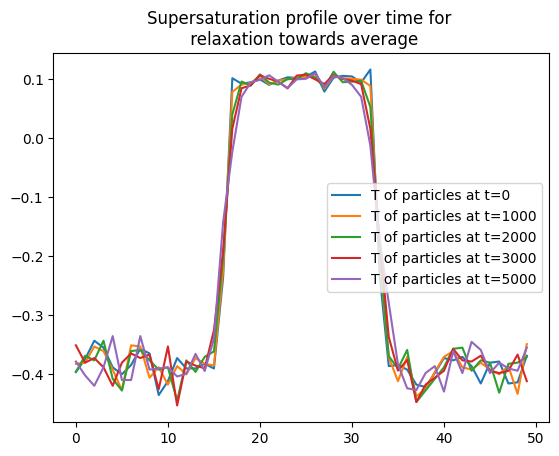

In [53]:
plt.plot(S_hist[0,:], label="T of particles at t=0")
plt.plot(S_hist[10,:], label="T of particles at t=1000")
plt.plot(S_hist[20,:], label="T of particles at t=2000")
plt.plot(S_hist[30,:], label="T of particles at t=3000")
plt.plot(S_hist[50,:], label="T of particles at t=5000")
plt.title("Supersaturation profile over time for \n relaxation towards average")
plt.legend()

In [11]:
nBins = 3
nSteps = 10000
NParticlesPerBin = np.zeros([nBins**2,nSteps])
print(NParticlesPerBin.shape)
posHist = np.zeros((2,nSteps))
U = np.zeros((N,2))
for i in tqdm(range(nSteps)):
    #hist = plt.hist2d(R[:,0], R[:,1], bins=nBins, range=[[0,L],[0,L]], cmap='plasma')
    for _ in range(1):
        R, U = step(R,U,0.1)
    #NParticlesPerBin[:,i] = hist[0].flatten()
    #NParticlesPerBin[:,i] = np.sum(R[:,0:1]//(L/nBins) == np.arange(nBins).reshape(1,-1),axis=1)[:,0] * nBins + np.sum(R[:,1:2]//(L/nBins) == np.arange(nBins).reshape(1,-1),axis=1)[:,0]   
    x,y = R[:,0], R[:,1]
    cell_x = np.floor(3 * x / L).astype(int)
    cell_y = np.floor(3 * y / L).astype(int)

    # Prevent edge-case overflow when x or y == L
    cell_x = np.clip(cell_x, 0, 2)
    cell_y = np.clip(cell_y, 0, 2)

    # Accumulate counts
    counts = np.zeros((3, 3), dtype=int)
    np.add.at(counts, (cell_x, cell_y), 1)
    NParticlesPerBin[:,i] = counts.flatten()
    posHist[:,i] = R[0,:]


    """edges = np.linspace(0, L, 4)  # 4 edges → 3 cells

    # Count particles per cell
    counts, xedges, yedges = np.histogram2d(x, y, bins=[edges, edges])

    NParticlesPerBin[:, i] = counts.flatten()"""


#Doesn't work very well
#plt.hist(NParticlesPerBin[0],bins = 10)

(9, 10000)


100%|██████████| 10000/10000 [05:07<00:00, 32.47it/s]


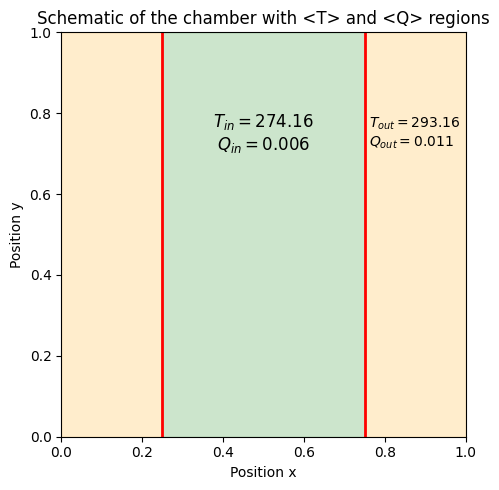

In [37]:
A = 275  # example value for T_in
B = 0.006  # example value for Q_in

fig, ax = plt.subplots(figsize=(5,5))

# Set axes limits
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Vertical red lines
ax.axvline(1/4, color='red', linewidth=2)
ax.axvline(3/4, color='red', linewidth=2)

# Green shaded region
ax.axvspan(1/4, 3/4, color='green', alpha=0.2)

#orange shaded regions
ax.axvspan(0, 1/4, color='orange', alpha=0.2)
ax.axvspan(3/4, 1, color='orange', alpha=0.2)


# Text in the middle
text = f"$T_{{in}} = {Tin}$\n$Q_{{in}} = {Qin:.3f}$"
ax.text(0.5, 0.75, text, ha='center', va='center', fontsize=12)

text2 = f"$T_{{out}} = {Tout}$\n$Q_{{out}} = {Qout:.3f}$"
ax.text(0.76, 0.75, text2, ha='left', va='center', fontsize=10)

# Make it look neat
ax.set_aspect('equal')
plt.xlabel('Position x')
plt.ylabel('Position y')
plt.title('Schematic of the chamber with <T> and <Q> regions')
plt.tight_layout()
plt.savefig('chamber_schematic.png', dpi=300)
plt.show()


In [38]:
#calculating S inside and ouside of the chamber at the end of the simulation
import numpy as np
import matplotlib.pyplot as plt
def analyse_S_hist(fileName):
    S_hist = np.loadtxt(fileName)
    S_final = S_hist[-1,:]
    print(S_hist.shape)
    #plt.plot(S_hist[-1, :], label=f'S at t={i*10}')
    #plt.legend()
    #plt.show()

    Average_S_inside = np.mean(S_final[16:34])
    Average_S_outside = np.mean(np.concatenate([S_final[:5], S_final[44:]]))
    #print(f"Average S inside the chamber: {Average_S_inside:.4f}")
    #print(f"Average S outside the chamber: {Average_S_outside:.4f}")

    Tin = float(fileName.split("_")[3].replace(".txt",""))
    Tout = float(fileName.split("_")[4].replace(".txt",""))
    print(Tin,Tout)
    Tin , Tout = np.min([Tin, Tout]), np.max([Tin, Tout])
    
    print(Tin, Tout)
    return [(Tin, Tout), (Average_S_inside, Average_S_outside)]

#analyse every file in SHIST folder with average relaxation mode
averages = []
import os
for file in os.listdir("SHIST"):
    if file.endswith(".txt") and "average" in file:
        print(f"Analyzing {file}...")
        averages.append(analyse_S_hist(os.path.join("SHIST", file)))



Analyzing S_hist_average_20_18.txt...
(100, 50)
20.0 18.0
18.0 20.0
Analyzing S_hist_average_10_20.txt...
(100, 50)
10.0 20.0
10.0 20.0
Analyzing S_hist_average_20_2.txt...
(100, 50)
20.0 2.0
2.0 20.0
